<h4>Import Data</h4>
The data is downloaded as a csv file.

In [3]:
import pandas as pd
data = pd.read_csv('data.csv')
data.head()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
0,6KbQ3uYMLKb5jDxLF7wYDD,Singende Bataillone 1. Teil,['Carl Woitschach'],158648,1928,1928,0.995,0.708,0.1950,0.563,0.1510,-12.428,0.0506,118.469,0.7790,1,10,0,0
1,6KuQTIu1KoTTkLXKrwlLPV,"Fantasiestücke, Op. 111: Più tosto lento","['Robert Schumann', 'Vladimir Horowitz']",282133,1928,1928,0.994,0.379,0.0135,0.901,0.0763,-28.454,0.0462,83.972,0.0767,1,8,0,0
2,6L63VW0PibdM1HDSBoqnoM,Chapter 1.18 - Zamek kaniowski,['Seweryn Goszczyński'],104300,1928,1928,0.604,0.749,0.2200,0.000,0.1190,-19.924,0.9290,107.177,0.8800,0,5,0,0
3,6M94FkXd15sOAOQYRnWPN8,Bebamos Juntos - Instrumental (Remasterizado),['Francisco Canaro'],180760,9/25/28,1928,0.995,0.781,0.1300,0.887,0.1110,-14.734,0.0926,108.003,0.7200,0,1,0,0
4,6N6tiFZ9vLTSOIxkj8qKrd,"Polonaise-Fantaisie in A-Flat Major, Op. 61","['Frédéric Chopin', 'Vladimir Horowitz']",687733,1928,1928,0.990,0.210,0.2040,0.908,0.0980,-16.829,0.0424,62.149,0.0693,1,11,1,0


<h4>Feature Selection</h4>
Select the data we will use and drop the useless data.<br>   
In this analysis, we do not consider mode, key, and explicit. 

In [4]:
data= data.drop(columns = ['release_date','mode','key','explicit'])
data.head()

,id,name,artists,duration_ms,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
0,6KbQ3uYMLKb5jDxLF7wYDD,Singende Bataillone 1. Teil,['Carl Woitschach'],158648,1928,0.995,0.708,0.1950,0.563,0.1510,-12.428,0.0506,118.469,0.7790,0
1,6KuQTIu1KoTTkLXKrwlLPV,"Fantasiestücke, Op. 111: Più tosto lento","['Robert Schumann', 'Vladimir Horowitz']",282133,1928,0.994,0.379,0.0135,0.901,0.0763,-28.454,0.0462,83.972,0.0767,0
2,6L63VW0PibdM1HDSBoqnoM,Chapter 1.18 - Zamek kaniowski,['Seweryn Goszczyński'],104300,1928,0.604,0.749,0.2200,0.000,0.1190,-19.924,0.9290,107.177,0.8800,0
3,6M94FkXd15sOAOQYRnWPN8,Bebamos Juntos - Instrumental (Remasterizado),['Francisco Canaro'],180760,1928,0.995,0.781,0.1300,0.887,0.1110,-14.734,0.0926,108.003,0.7200,0
4,6N6tiFZ9vLTSOIxkj8qKrd,"Polonaise-Fantaisie in A-Flat Major, Op. 61","['Frédéric Chopin', 'Vladimir Horowitz']",687733,1928,0.990,0.210,0.2040,0.908,0.0980,-16.829,0.0424,62.149,0.0693,1


<h4>Convert datatype</h4>
Convert all features that will be used for clustering into a float datatype for better accuracy.


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169909 entries, 0 to 169908
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                169909 non-null  object 
 1   name              169909 non-null  object 
 2   artists           169909 non-null  object 
 3   duration_ms       169909 non-null  int64  
 4   year              169909 non-null  int64  
 5   acousticness      169909 non-null  float64
 6   danceability      169909 non-null  float64
 7   energy            169909 non-null  float64
 8   instrumentalness  169909 non-null  float64
 9   liveness          169909 non-null  float64
 10  loudness          169909 non-null  float64
 11  speechiness       169909 non-null  float64
 12  tempo             169909 non-null  float64
 13  valence           169909 non-null  float64
 14  popularity        169909 non-null  int64  
dtypes: float64(9), int64(3), object(3)
memory usage: 19.4+ MB


In [6]:
data["duration_ms"] = data["duration_ms"].astype(float)

<h4>Check and deal with Null if any</h4>

In [7]:
print(data.isnull().sum())

id                  0
name                0
artists             0
duration_ms         0
year                0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
dtype: int64


<h4>Exclude Outliers</h4>
Plot to check the distribution for a suitable outlier removal approach.

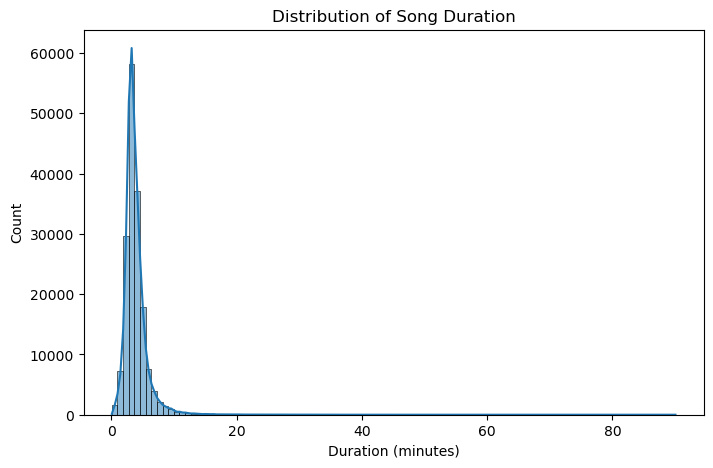

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

data["duration_min"] = data["duration_ms"] / 60000

plt.figure(figsize=(8,5))
sns.histplot(data["duration_min"], bins=100, kde=True)

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")

plt.show()

We choose to use the IQR method to remove outliers.<br>
The IQR method is a robust statistical approach that is less sensitive to extreme values and does not assume a normal distribution.

Since the duration distribution is right-skewed with a long tail, an asymmetric rule was applied: <br>
Q1 - 1.5 * IQR for the lower bound to remove unusually short tracks (ie, intro, outro, etc.)<br>
Q3 + 3 * IQR for the upper bound to retain longer but valid songs(ie, classic music tracks) while removing extreme outliers.

In [9]:
# calculate Q1, Q3, IQR
Q1 = data["duration_ms"].quantile(0.25)
Q3 = data["duration_ms"].quantile(0.75)
IQR = Q3 - Q1

# define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 3 * IQR

print('Lower_bound:',lower_bound / 60000,' minutes')
print('Upper_bound:',upper_bound / 60000,' minutes')

# count the number of outliers under this threshold.
lower_outliers = (data["duration_ms"] < lower_bound).sum()
upper_outliers = (data["duration_ms"] > upper_bound).sum()
normal_range = ((data["duration_ms"] >= lower_bound) & (data["duration_ms"] <= upper_bound)).sum()

print("Lower outliers:", lower_outliers)
print("Upper outliers:", upper_outliers)
print("Normal range:", normal_range)

Lower_bound: 0.5526666666666666  minutes
Upper_bound: 8.978666666666667  minutes
Lower outliers: 287
Upper outliers: 3384
Normal range: 166238


In [10]:
data_clean = data[(data["duration_ms"] >= lower_bound) & (data["duration_ms"] <= upper_bound)]

In [13]:
print("Original data:", len(data))
print("Clean data:", len(data_clean))

Original data: 169909
Clean data: 166238


<h4>Standarization</h4>

In [14]:
from sklearn.preprocessing import StandardScaler

# define audio features for cluster
features = [
    "duration_ms",
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]
X = data_clean[features]

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#store scaled data back into dataframe
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features
)

Check the standardization result<br>
Check wether the mean ≈ 0 and std ≈ 1

In [15]:
X_scaled.describe()

,duration_ms,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05,1.662380e+05
mean,1.439567e-16,4.376832e-17,4.568318e-16,-2.461968e-17,-9.984647e-17,-8.531403e-17,-1.778088e-17,-4.111828e-17,-2.636357e-16,-6.667830e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.376506e+00,-1.299991e+00,-3.118072e+00,-1.843342e+00,-5.121126e-01,-1.175357e+00,-8.678052e+00,-6.318452e-01,-3.814901e+00,-2.060470e+00
25%,-6.369688e-01,-1.056486e+00,-6.883432e-01,-8.426778e-01,-5.121126e-01,-6.136060e-01,-5.404778e-01,-3.960952e-01,-7.614882e-01,-7.975916e-01
50%,-1.722219e-01,-1.901314e-02,5.439364e-02,-2.565584e-02,-5.115484e-01,-4.038779e-01,1.586821e-01,-3.271941e-01,-7.131508e-02,4.688634e-02
75%,4.848576e-01,1.046697e+00,7.337964e-01,8.288442e-01,-2.805301e-01,3.218841e-01,7.492105e-01,-1.204907e-01,6.102294e-01,8.299477e-01
max,4.029677e+00,1.347009e+00,2.570487e+00,1.904465e+00,2.768093e+00,4.539304e+00,2.693538e+00,5.913763e+00,4.132875e+00,1.778066e+00


<h4>Split data into decades for further analysis</h4>

In [16]:
import pandas as pd

# define bins for decades
bins = list(range(1921, 2022, 10))  
labels = [f"{b}-{b+9}" for b in bins[:-1]]

data_clean["decade"] = pd.cut(data_clean["year"], 
                        bins=bins, 
                        labels=labels, 
                        right=False)

/var/folders/gb/rsytx1k509xghtqlwnd56lp80000gn/T/ipykernel_63396/3813915337.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean["decade"] = pd.cut(data_clean["year"],


In [17]:
data_clean["decade"].value_counts().sort_index()

decade
1921-1930     6144
1931-1940     8771
1941-1950    14201
1951-1960    19151
1961-1970    19518
1971-1980    19459
1981-1990    19751
1991-2000    19805
2001-2010    19862
2011-2020    19576
Name: count, dtype: int64

<h4>Save to csv file

In [18]:
data_clean.to_csv("data_clean.csv", index=False)